In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Week 1 – Monthly Dataset Aggregation**

In [3]:
sold = pd.read_csv("sold_combined.csv")
listed = pd.read_csv("listed_combined.csv")

/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_41703/3516636363.py:1: DtypeWarning: Columns (0,1,4,9,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("sold_combined.csv")
/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_41703/3516636363.py:2: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  listed = pd.read_csv("listed_combined.csv")


### **Basic shape and column info**

In [4]:
print("SOLD SHAPE:", sold.shape)
print("LISTED SHAPE:", listed.shape)

print("\nSOLD COLUMNS:")
print(sold.columns.tolist())

print("\nLISTED COLUMNS:")
print(listed.columns.tolist())

SOLD SHAPE: (568183, 84)
LISTED SHAPE: (814004, 84)

SOLD COLUMNS:
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal',

In [5]:
sold.info()
listed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568183 entries, 0 to 568182
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 498634 non-null  object 
 1   ListAgentAOR                  500146 non-null  object 
 2   Flooring                      334069 non-null  object 
 3   ViewYN                        511151 non-null  object 
 4   WaterfrontYN                  313 non-null     object 
 5   BasementYN                    9393 non-null    object 
 6   PoolPrivateYN                 496545 non-null  object 
 7   OriginalListPrice             566540 non-null  float64
 8   ListingKey                    568183 non-null  int64  
 9   ListAgentEmail                547714 non-null  object 
 10  CloseDate                     568183 non-null  object 
 11  ClosePrice                    568176 non-null  float64
 12  ListAgentFirstName            564855 non-nul

### **Check property types**

In [6]:
print("Sold property types:")
print(sold["PropertyType"].value_counts(dropna=False))

print("\nListed property types:")
print(listed["PropertyType"].value_counts(dropna=False))

Sold property types:
PropertyType
Residential            381849
ResidentialLease       130090
Land                    18564
ManufacturedInPark      15433
ResidentialIncome       15295
CommercialSale           3568
CommercialLease          2992
BusinessOpportunity       392
Name: count, dtype: int64

Listed property types:
PropertyType
Residential            514651
ResidentialLease       170875
Land                    53851
ResidentialIncome       29954
ManufacturedInPark      23451
CommercialSale          11189
CommercialLease          7401
BusinessOpportunity      2632
Name: count, dtype: int64


In [7]:
# Filter to Residential ONLY
sold_res = sold[sold["PropertyType"] == "Residential"].copy()
listed_res = listed[listed["PropertyType"] == "Residential"].copy()

print("Sold before:", len(sold))
print("Sold after Residential filter:", len(sold_res))

print("Listed before:", len(listed))
print("Listed after Residential filter:", len(listed_res))

Sold before: 568183
Sold after Residential filter: 381849
Listed before: 814004
Listed after Residential filter: 514651


In [8]:
sold_res.to_csv("sold_residential.csv", index=False)
listed_res.to_csv("listed_residential.csv", index=False)

print("\nFiles saved successfully!")


Files saved successfully!


## **Weeks 2–3 – Dataset Structuring and Validation**

Load Residential datasets
Inspect shape and columns
Check data types
Missing value summary
Flag columns above 90% null
Numeric summaries
Histograms and boxplots
Answer key EDA questions
Save validated datasets

### **1. Load Residential datasets**

In [9]:
sold_res = pd.read_csv("sold_residential.csv", low_memory=False)
listed_res = pd.read_csv("listed_residential.csv", low_memory=False)

This loads the Residential-only datasets from Week 1. Using low_memory=False helps avoid mixed-type warnings when pandas reads large CSVs.

### **2. Basic shape check**

In [10]:
print("SOLD SHAPE:", sold_res.shape)
print("LISTED SHAPE:", listed_res.shape)
sold_res.head()

SOLD SHAPE: (381849, 84)
LISTED SHAPE: (514651, 84)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [11]:
listed_res.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [12]:
# View columns
print(sold_res.columns.tolist())
print(listed_res.columns.tolist())

# # This helps identify:
#     + key market variables
# `   + possible metadata columns
#     + columns that may matter later for feature engineering and Tableau

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [13]:
print(sold_res.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381849 entries, 0 to 381848
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 334409 non-null  object 
 1   ListAgentAOR                  335666 non-null  object 
 2   Flooring                      244968 non-null  object 
 3   ViewYN                        349223 non-null  object 
 4   WaterfrontYN                  240 non-null     object 
 5   BasementYN                    7491 non-null    object 
 6   PoolPrivateYN                 348497 non-null  object 
 7   OriginalListPrice             381166 non-null  float64
 8   ListingKey                    381849 non-null  int64  
 9   ListAgentEmail                368591 non-null  object 
 10  CloseDate                     381849 non-null  object 
 11  ClosePrice                    381847 non-null  float64
 12  ListAgentFirstName            378944 non-nul

In [14]:
print(listed_res.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514651 entries, 0 to 514650
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             513915 non-null  float64
 1   ListingKey                    514651 non-null  int64  
 2   ListAgentEmail                493182 non-null  object 
 3   CloseDate                     162652 non-null  object 
 4   ClosePrice                    143614 non-null  float64
 5   ListAgentFirstName            510619 non-null  object 
 6   ListAgentLastName             514612 non-null  object 
 7   Latitude                      434798 non-null  float64
 8   Longitude                     434798 non-null  float64
 9   UnparsedAddress               514031 non-null  object 
 10  PropertyType                  514651 non-null  object 
 11  LivingArea                    514125 non-null  float64
 12  ListPrice                     514651 non-nul

Checking:

    which columns are numeric
    which are objects/text
    which columns have lots of missing values
    whether date columns are still strings

This matters because some columns that should be numeric may still be stored as text.

In [15]:
# Confirm Residential-only
print(sold_res["PropertyType"].value_counts(dropna=False))
print(listed_res["PropertyType"].value_counts(dropna=False))

PropertyType
Residential    381849
Name: count, dtype: int64
PropertyType
Residential    514651
Name: count, dtype: int64


In [16]:
# Missing value summary for sold
sold_nulls = pd.DataFrame({
    "null_count": sold_res.isnull().sum(),
    "null_pct": sold_res.isnull().mean() * 100
}).sort_values("null_pct", ascending=False)

sold_nulls.head(20)

,null_count,null_pct
CoveredSpaces,381849,100.000000
MiddleOrJuniorSchoolDistrict,381849,100.000000
AboveGradeFinishedArea,381849,100.000000
FireplacesTotal,381849,100.000000
TaxYear,381849,100.000000
ElementarySchoolDistrict,381849,100.000000
BusinessType,381849,100.000000
TaxAnnualAmount,381849,100.000000
WaterfrontYN,381609,99.937148
BelowGradeFinishedArea,379652,99.424642


In [17]:
# Missing value summary for listed
listed_nulls = pd.DataFrame({
    "null_count": listed_res.isnull().sum(),
    "null_pct": listed_res.isnull().mean() * 100
}).sort_values("null_pct", ascending=False)

listed_nulls.head(20)

,null_count,null_pct
TaxAnnualAmount,514651,100.000000
FireplacesTotal,514651,100.000000
ElementarySchoolDistrict,514651,100.000000
TaxYear,514651,100.000000
BusinessType,514651,100.000000
MiddleOrJuniorSchoolDistrict,514651,100.000000
CoveredSpaces,514651,100.000000
AboveGradeFinishedArea,514651,100.000000
BelowGradeFinishedArea,511790,99.444089
CoBuyerAgentFirstName,500476,97.245706


Several columns exhibit extremely high missingness, with some variables containing 100% null values and others exceeding 99% missingness. These columns provide little to no analytical value and will be removed in later data cleaning steps to improve dataset quality and efficiency.

In [18]:
# Flag columns above 90% missing
print("Sold columns > 90% null:")
display(sold_nulls[sold_nulls["null_pct"] > 90])

print("Listed columns > 90% null:")
display(listed_nulls[listed_nulls["null_pct"] > 90])

Sold columns > 90% null:


,null_count,null_pct
CoveredSpaces,381849,100.000000
MiddleOrJuniorSchoolDistrict,381849,100.000000
AboveGradeFinishedArea,381849,100.000000
FireplacesTotal,381849,100.000000
TaxYear,381849,100.000000
ElementarySchoolDistrict,381849,100.000000
BusinessType,381849,100.000000
TaxAnnualAmount,381849,100.000000
WaterfrontYN,381609,99.937148
BelowGradeFinishedArea,379652,99.424642


Listed columns > 90% null:


,null_count,null_pct
TaxAnnualAmount,514651,100.000000
FireplacesTotal,514651,100.000000
ElementarySchoolDistrict,514651,100.000000
TaxYear,514651,100.000000
BusinessType,514651,100.000000
MiddleOrJuniorSchoolDistrict,514651,100.000000
CoveredSpaces,514651,100.000000
AboveGradeFinishedArea,514651,100.000000
BelowGradeFinishedArea,511790,99.444089
CoBuyerAgentFirstName,500476,97.245706



===== ClosePrice =====
count    3.818470e+05
mean     1.186041e+06
std      6.000621e+06
min      0.000000e+00
25%      5.750000e+05
50%      8.213000e+05
75%      1.300000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64
Percentiles:
0.01     203000.0
0.25     575000.0
0.50     821300.0
0.75    1300000.0
0.99    5536350.0
Name: ClosePrice, dtype: float64


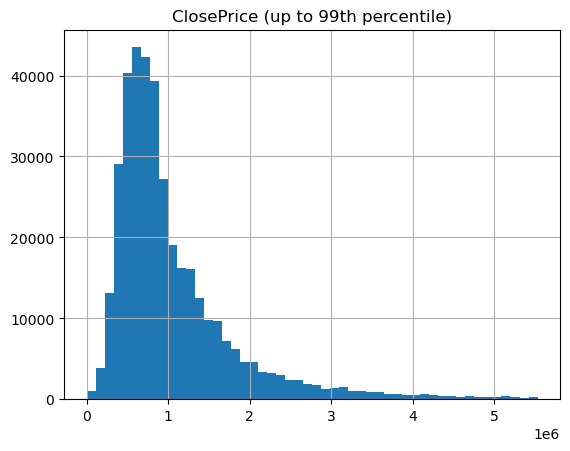


===== ListPrice =====
count    3.818490e+05
mean     1.138088e+06
std      1.350432e+06
min      5.250000e+02
25%      5.760000e+05
50%      8.150000e+05
75%      1.295000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64
Percentiles:
0.01     215000.0
0.25     576000.0
0.50     815000.0
0.75    1295000.0
0.99    5695000.0
Name: ListPrice, dtype: float64


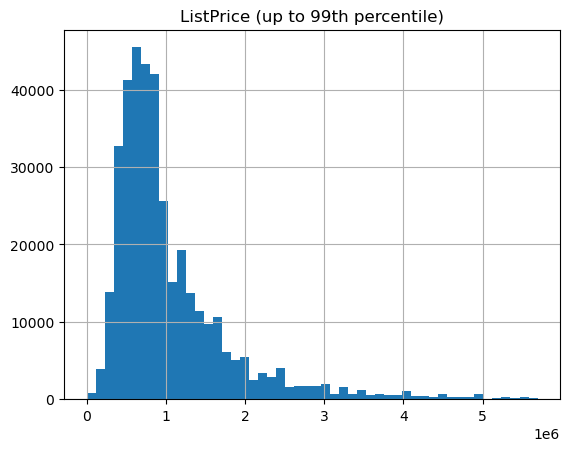


===== OriginalListPrice =====
count    3.811660e+05
mean     1.226498e+06
std      6.908455e+06
min      0.000000e+00
25%      5.850000e+05
50%      8.250000e+05
75%      1.299000e+06
max      1.390000e+09
Name: OriginalListPrice, dtype: float64
Percentiles:
0.01     212787.2
0.25     585000.0
0.50     825000.0
0.75    1299000.0
0.99    5995000.0
Name: OriginalListPrice, dtype: float64


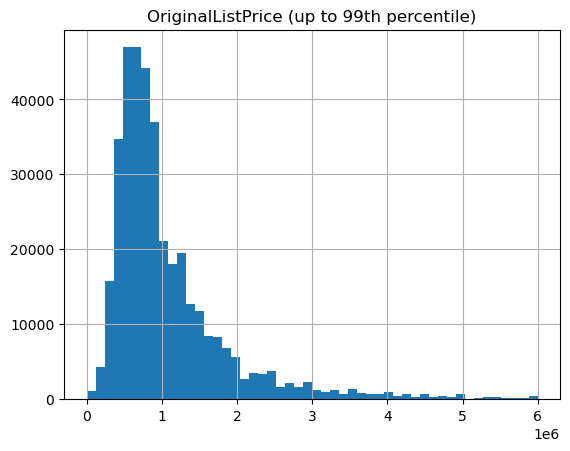


===== LivingArea =====
count    3.816240e+05
mean     1.905221e+03
std      2.756893e+04
min      0.000000e+00
25%      1.246000e+03
50%      1.640000e+03
75%      2.216000e+03
max      1.702132e+07
Name: LivingArea, dtype: float64
Percentiles:
0.01     603.0
0.25    1246.0
0.50    1640.0
0.75    2216.0
0.99    5280.0
Name: LivingArea, dtype: float64


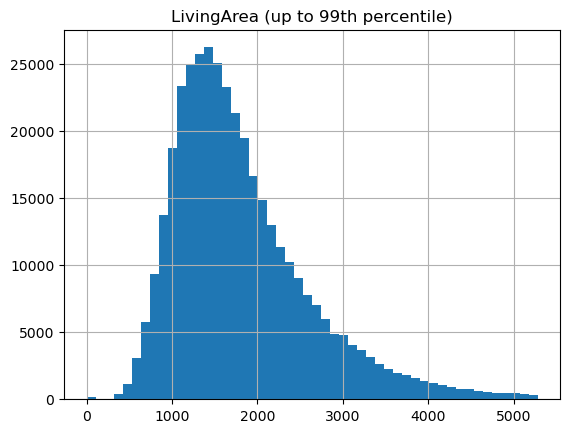


===== LotSizeAcres =====
count    3.516080e+05
mean     7.015075e+01
std      1.666092e+04
min      0.000000e+00
25%      1.200000e-01
50%      1.663000e-01
75%      2.708000e-01
max      7.810698e+06
Name: LotSizeAcres, dtype: float64
Percentiles:
0.01     0.0000
0.25     0.1200
0.50     0.1663
0.75     0.2708
0.99    10.7983
Name: LotSizeAcres, dtype: float64


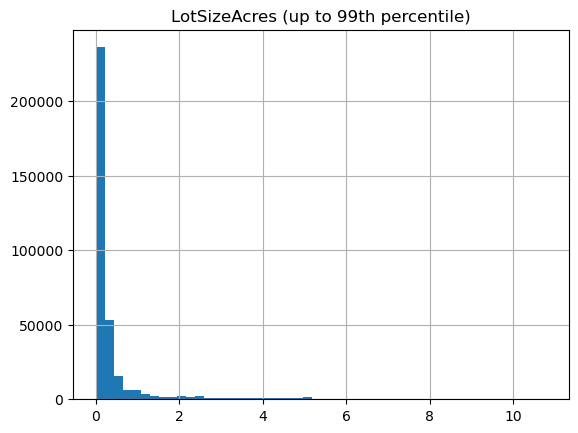


===== BedroomsTotal =====
count    381838.000000
mean          3.199878
std           1.067489
min           0.000000
25%           3.000000
50%           3.000000
75%           4.000000
max          45.000000
Name: BedroomsTotal, dtype: float64
Percentiles:
0.01    1.0
0.25    3.0
0.50    3.0
0.75    4.0
0.99    6.0
Name: BedroomsTotal, dtype: float64


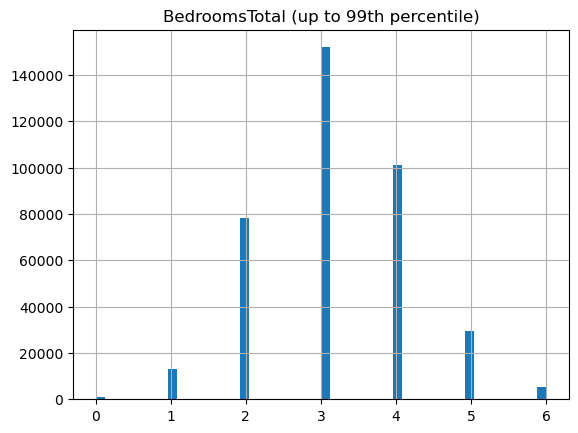


===== BathroomsTotalInteger =====
count    381781.000000
mean          2.532211
std           1.138093
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64
Percentiles:
0.01    1.0
0.25    2.0
0.50    2.0
0.75    3.0
0.99    6.0
Name: BathroomsTotalInteger, dtype: float64


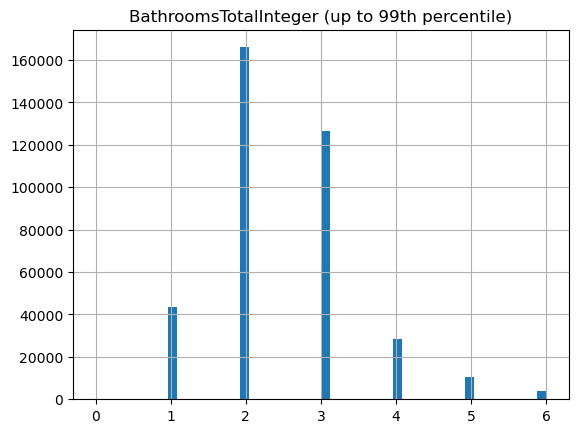


===== DaysOnMarket =====
count    381849.000000
mean         37.108962
std          53.146321
min        -288.000000
25%           8.000000
50%          19.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64
Percentiles:
0.01      0.0
0.25      8.0
0.50     19.0
0.75     48.0
0.99    227.0
Name: DaysOnMarket, dtype: float64


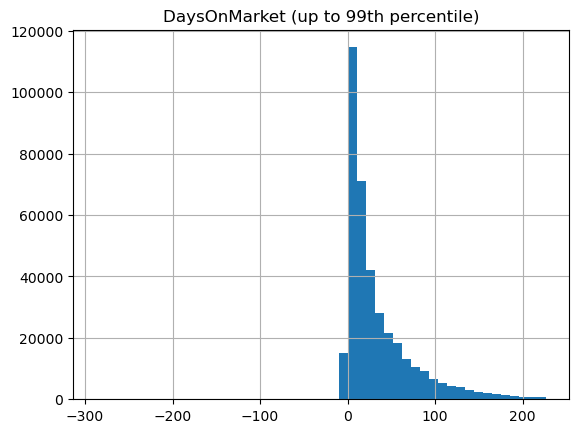


===== YearBuilt =====
count    381503.000000
mean       1978.522583
std          26.267712
min        1776.000000
25%        1960.000000
50%        1979.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64
Percentiles:
0.01    1912.0
0.25    1960.0
0.50    1979.0
0.75    1999.0
0.99    2025.0
Name: YearBuilt, dtype: float64


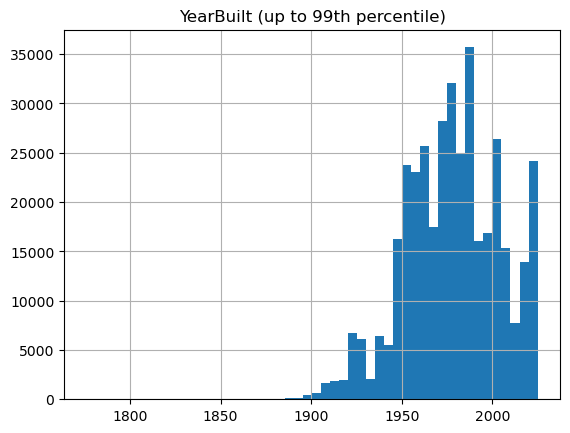

In [19]:

numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

for col in numeric_cols:
    print(f"\n===== {col} =====")

    # Drop nulls
    data = sold_res[col].dropna()

    # Summary stats
    print(data.describe())

    # Percentiles
    print("Percentiles:")
    print(data.quantile([0.01, 0.25, 0.5, 0.75, 0.99]))

    # Histogram (with 99% filter for readability)
    upper = data.quantile(0.99)
    data[data <= upper].hist(bins=50)
    plt.title(f"{col} (up to 99th percentile)")
    plt.show()


1. Price Variables

(ClosePrice, ListPrice, OriginalListPrice)

All three distributions are heavily right-skewed
Most properties are concentrated around: roughly $300K – $1M
There is a long right tail extending to multi-million properties
The shapes are very similar across all three variables
=> This indicates a consistent pricing structure, with most homes in a typical range and a small number of luxury properties acting as outliers.

2. LivingArea
Also right-skewed, but much cleaner
Most homes fall between:
~1000 – 2500 sqft
Gradual decline toward larger homes

=> It follows a realistic distribution, with most homes in a typical size range and fewer large properties.

3. LotSizeAcres
Extremely skewed toward 0
Majority of values are very small
Some extreme large values (up to ~10+ acres)

=< Lot size is highly skewed, with most properties having small lot sizes and a few very large parcels, likely representing rural or special properties.

4. BedroomsTotal
- Discrete distribution
- Most homes have:
  + 2–4 bedrooms
- Very few extreme values (5–6+)

=> Bedroom count is well-behaved and concentrated in typical residential ranges.

#### Key Pattern
Across most variables, the data shows strong right-skewness with long tails, indicating the presence of extreme outliers.

In [23]:
# Optional broader numeric review
extra_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]
existing_cols = [col for col in extra_cols if col in sold.columns]
display(sold_res[existing_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,381847.0,1.186041e+06,6.000621e+06,0.0,203000.0,340000.00,575000.00,821300.0000,1.300000e+06,2.850000e+06,5.536350e+06,9.895000e+08
ListPrice,381849.0,1.138088e+06,1.350432e+06,525.0,215000.0,347000.00,576000.00,815000.0000,1.295000e+06,2.850000e+06,5.695000e+06,1.375000e+08
OriginalListPrice,381166.0,1.226498e+06,6.908455e+06,0.0,212787.2,349900.00,585000.00,825000.0000,1.299000e+06,2.899000e+06,5.995000e+06,1.390000e+09
LivingArea,381624.0,1.905221e+03,2.756893e+04,0.0,603.0,838.00,1246.00,1640.0000,2.216000e+03,3.557000e+03,5.280000e+03,1.702132e+07
LotSizeAcres,351608.0,7.015075e+01,1.666092e+04,0.0,0.0,0.03,0.12,0.1663,2.708000e-01,2.794135e+00,1.079830e+01,7.810698e+06
BedroomsTotal,381838.0,3.199878e+00,1.067489e+00,0.0,1.0,2.00,3.00,3.0000,4.000000e+00,5.000000e+00,6.000000e+00,4.500000e+01
BathroomsTotalInteger,381781.0,2.532211e+00,1.138093e+00,0.0,1.0,1.00,2.00,2.0000,3.000000e+00,4.000000e+00,6.000000e+00,1.750000e+02
DaysOnMarket,381849.0,3.710896e+01,5.314632e+01,-288.0,0.0,1.00,8.00,19.0000,4.800000e+01,1.300000e+02,2.270000e+02,1.243000e+04
YearBuilt,381503.0,1.978523e+03,2.626771e+01,1776.0,1912.0,1930.00,1960.00,1979.0000,1.999000e+03,2.022000e+03,2.025000e+03,2.026000e+03


The distribution of DaysOnMarket is right-skewed, with most properties selling within a relatively short time frame. However, the presence of negative values indicates data quality issues, likely due to inconsistencies in date calculations or recording errors. These records will need to be addressed during data cleaning.

In [28]:
sold_res[sold_res["DaysOnMarket"] < 0].shape


(46, 84)

In [29]:
sold_res[sold_res["DaysOnMarket"] < 0].head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
6,CoastalMendocino,CoastalMendocino,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,...,95437,NaN,74487.6,NaN,CRMLS,CRMLS_CRF,NaN,NaN,NaN,NaN
11214,NaN,NaN,"Carpet,Tile",True,NaN,NaN,True,899000.0,1062122119,thewalkers@bdhomes.com,...,92210,650.0,4792.0,NaN,NaN,NaN,Item1,3.0,NaN,NaN
11381,NaN,NaN,NaN,False,NaN,NaN,False,372000.0,1061302766,hello@yourdesertlife.org,...,92507,NaN,10454.0,NaN,NaN,NaN,Item,7000.0,NaN,NaN
18698,NaN,NaN,NaN,False,NaN,NaN,False,699900.0,1052574395,kristyglinski@gmail.com,...,93036,NaN,6190.0,NaN,NaN,NaN,Item1,2.5,NaN,NaN
23005,NaN,NaN,"Carpet,Vinyl",False,NaN,NaN,False,485410.0,1045653374,rhsaenz@drhorton.com,...,92223,176.0,5166.0,NaN,NaN,NaN,Item1,2.0,NaN,NaN


A small number of records (46 observations) contain negative DaysOnMarket values, which are not logically valid. These likely result from inconsistencies in date calculations or data entry errors. These records will be addressed during the data cleaning phase.

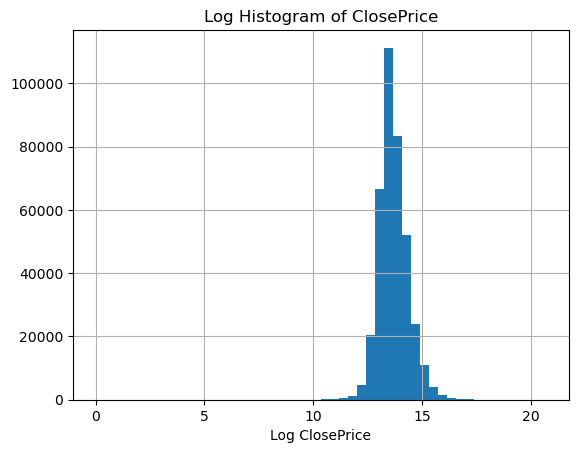

In [30]:
sold_res["ClosePrice_log"] = np.log1p(sold_res["ClosePrice"])

sold_res["ClosePrice_log"].hist(bins=50)
plt.title("Log Histogram of ClosePrice")
plt.xlabel("Log ClosePrice")
plt.show()

Plotting ClosePrice...


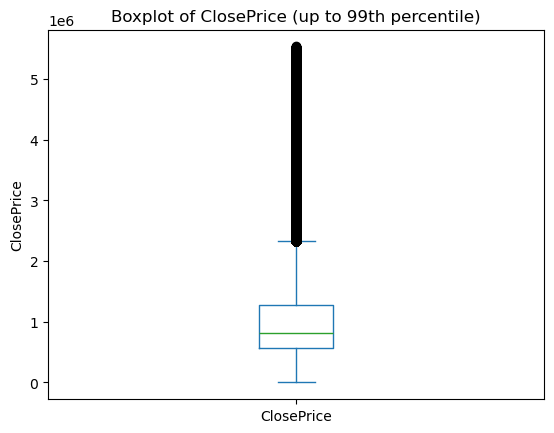

Plotting ListPrice...


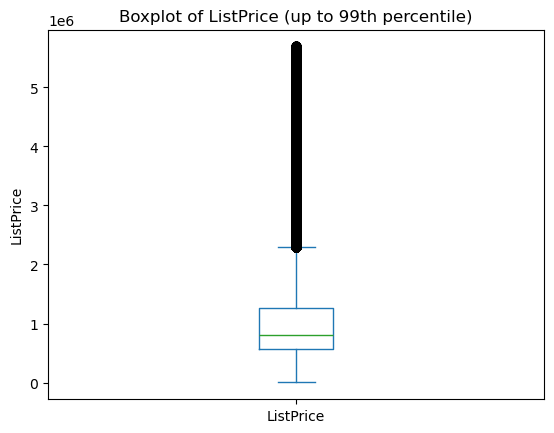

Plotting OriginalListPrice...


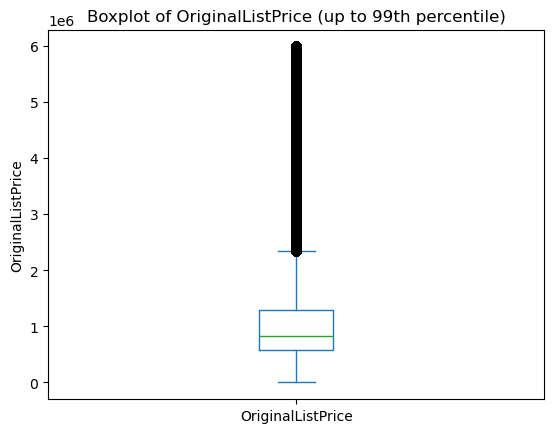

Plotting LivingArea...


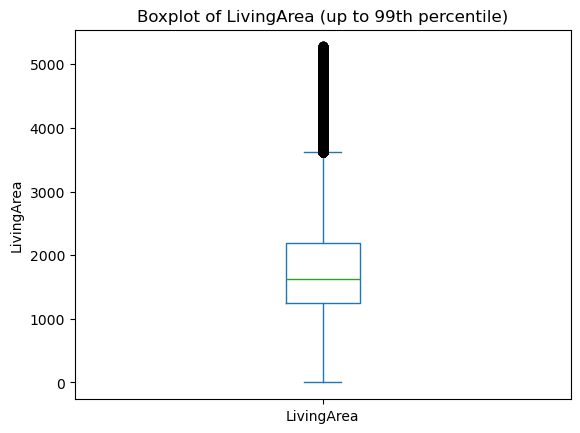

Plotting LotSizeAcres...


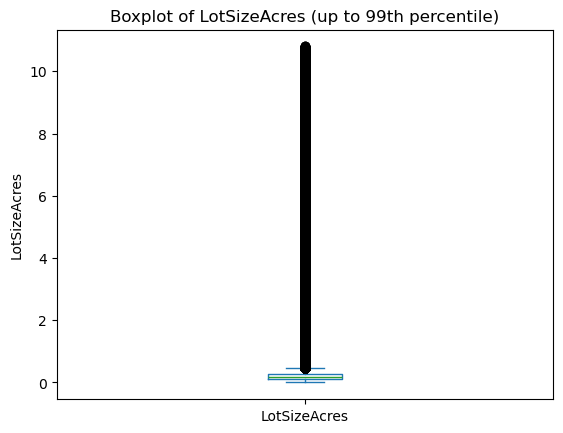

Plotting BedroomsTotal...


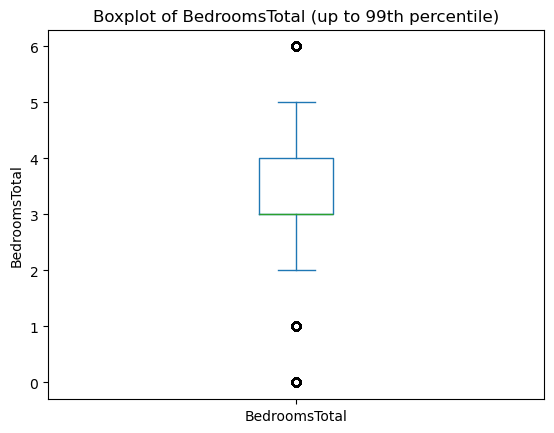

Plotting BathroomsTotalInteger...


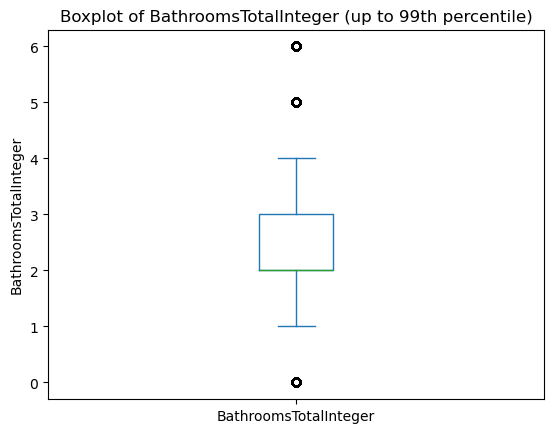

Plotting DaysOnMarket...


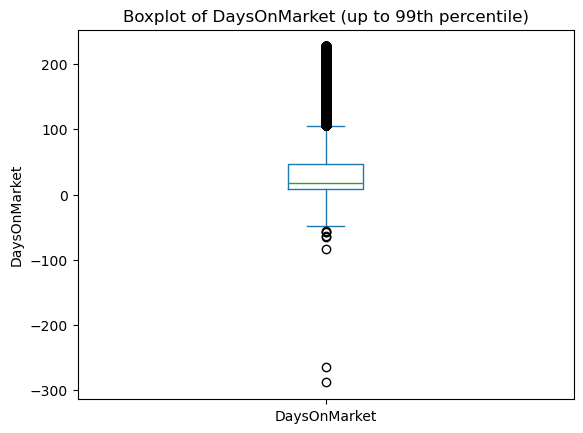

Plotting YearBuilt...


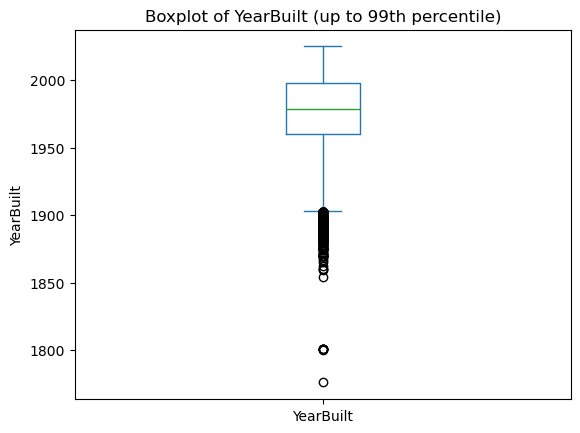

In [21]:

for col in numeric_cols:
    print(f"Plotting {col}...")

    # drop missing values
    data = sold_res[col].dropna()

    # limit to 99th percentile (VERY IMPORTANT for your dataset)
    upper = data.quantile(0.99)
    data_filtered = data[data <= upper]

    # plot
    plt.figure()
    data_filtered.plot.box()
    plt.title(f"Boxplot of {col} (up to 99th percentile)")
    plt.ylabel(col)
    plt.show()

Across all numeric variables, the data shows strong right-skewness with many extreme outliers, especially in price and lot size variables.

Price variables are highly skewed with a large number of high-value outliers, indicating the presence of luxury properties.

Living area is more stable, with most homes in a typical range and a smaller number of large properties.

Lot size is extremely skewed, with most properties having small lot sizes and a few extreme values representing large parcels.

Bedroom counts are well-distributed but include some unrealistic values such as zero-bedroom entries.

Bathroom counts are generally consistent but contain some invalid entries.

Days on Market shows a right-skewed distribution, with most homes selling quickly, but also includes invalid negative values that must be cleaned.

Year built is relatively well-distributed, though some very old values may require validation.

In [22]:
sold_res.to_csv("sold_validated.csv", index=False)
listed_res.to_csv("listed_validated.csv", index=False)

### **Fetch mortgage data**

In [37]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url)

print(mortgage.head())
print(mortgage.columns)

  observation_date  MORTGAGE30US
0       1971-04-02          7.33
1       1971-04-09          7.31
2       1971-04-16          7.31
3       1971-04-23          7.31
4       1971-04-30          7.29
Index(['observation_date', 'MORTGAGE30US'], dtype='object')


In [38]:
# rename columns correctly
mortgage = mortgage.rename(columns={
    "observation_date": "date",
    "MORTGAGE30US": "rate_30yr_fixed"
})

# convert to datetime
mortgage["date"] = pd.to_datetime(mortgage["date"], errors="coerce")

mortgage.head()

,date,rate_30yr_fixed
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [39]:
mortgage["year_month"] = mortgage["date"].dt.to_period("M")

mortgage_monthly = (
    mortgage.groupby("year_month")["rate_30yr_fixed"]
    .mean()
    .reset_index()
)

mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [40]:
# create keys
sold_res["CloseDate"] = pd.to_datetime(sold_res["CloseDate"], errors="coerce")
listed_res["ListingContractDate"] = pd.to_datetime(listed_res["ListingContractDate"], errors="coerce")

sold_res["year_month"] = sold_res["CloseDate"].dt.to_period("M")
listed_res["year_month"] = listed_res["ListingContractDate"].dt.to_period("M")

# merge
sold_with_rates = sold_res.merge(mortgage_monthly, on="year_month", how="left")
listed_with_rates = listed_res.merge(mortgage_monthly, on="year_month", how="left")

In [41]:
print(sold_with_rates["rate_30yr_fixed"].isnull().sum())
print(listed_with_rates["rate_30yr_fixed"].isnull().sum())

0
0


In [42]:
sold_with_rates.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,ClosePrice_log,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,12.388398,2024-01,6.6425
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN,13.610945,2024-01,6.6425
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN,13.604791,2024-01,6.6425
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,13.662361,2024-01,6.6425
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,14.452352,2024-01,6.6425


In [43]:
print("rate_30yr_fixed" in sold_with_rates.columns)

True


Mortgage rate data from FRED was successfully merged with the MLS datasets using a monthly time key. Validation checks confirmed that the merged datasets contain minimal or no missing mortgage rate values, indicating a successful join.

In [44]:
sold_with_rates.to_csv("sold_with_mortgage_rates.csv", index=False)
listed_with_rates.to_csv("listed_with_mortgage_rates.csv", index=False)